# Proyek Klasifikasi Gambar: Crop Disease Datasets
- **Nama:** Fakhri Akmal
- **Email:** fakhrijongkeng12@gmail.com
- **ID Dicoding:** fakhri_akmal

## Import Semua Packages/Library yang Digunakan

In [ ]:
# Install tensorflowjs
!pip install tensorflowjs --quiet


In [ ]:
## BASE MODULE ##
import os, shutil
import zipfile
import random
from random import sample
import shutil
from shutil import copyfile
import pathlib
from pathlib import Path
import numpy as np
import pandas as pd
from tqdm.notebook import tqdm as tq

## MODULE FOR PROCESSING ##
import cv2
from PIL import Image
import skimage
from skimage import io
from skimage.transform import resize
from skimage.transform import rotate, AffineTransform, warp
from skimage import img_as_ubyte
from skimage.exposure import adjust_gamma
from skimage.util import random_noise

## MODULE FOR DEVELOPE MODEL ##
import keras
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf
from tensorflow.keras import Model, layers
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img
from tensorflow.keras.optimizers import Adam, RMSprop, SGD
from tensorflow.keras.layers import InputLayer, Conv2D, SeparableConv2D, MaxPooling2D, MaxPool2D, Dense, Flatten, Dropout, BatchNormalization
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.applications.densenet import DenseNet121
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import ModelCheckpoint, Callback, EarlyStopping, ReduceLROnPlateau

##
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

## Data Preparation

### Data Loading

In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"fakhrijongkeng","key":"KGAT_be1badf15f13a3f4e98d1a6af4586da1"}'}

In [ ]:
!mkdir -p ~/.kaggle

!cp kaggle.json ~/.kaggle/

!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d shubham2703/five-crop-diseases-dataset
!unzip five-crop-diseases-dataset.zip

Streaming output truncated to the last 5000 lines.
  inflating: Crop Diseases Dataset/Crop Diseases/Crop___Disease/Rice/Rice___Leaf_Blast/IMG_20190419_125251.jpg  
  inflating: Crop Diseases Dataset/Crop Diseases/Crop___Disease/Rice/Rice___Leaf_Blast/IMG_20190419_125403.jpg  
  inflating: Crop Diseases Dataset/Crop Diseases/Crop___Disease/Rice/Rice___Leaf_Blast/IMG_20190419_125426.jpg  
  inflating: Crop Diseases Dataset/Crop Diseases/Crop___Disease/Rice/Rice___Leaf_Blast/IMG_20190419_125429.jpg  
  inflating: Crop Diseases Dataset/Crop Diseases/Crop___Disease/Rice/Rice___Leaf_Blast/IMG_20190419_125436.jpg  
  inflating: Crop Diseases Dataset/Crop Diseases/Crop___Disease/Rice/Rice___Leaf_Blast/IMG_20190419_125441.jpg  
  inflating: Crop Diseases Dataset/Crop Diseases/Crop___Disease/Rice/Rice___Leaf_Blast/IMG_20190419_125504.jpg  
  inflating: Crop Diseases Dataset/Crop Diseases/Crop___Disease/Rice/Rice___Leaf_Blast/IMG_20190419_130528.jpg  
  inflating: Crop Diseases Dataset/Crop Disea

In [ ]:
import os
import shutil
import re

root_path = '/content/Crop Diseases Dataset/Crop Diseases/Crop___Disease/sugarcane'

# Iterate through the items in the directory
for folder_name in os.listdir(root_path):
    folder_path = os.path.join(root_path, folder_name)

    # Check if it's actually a directory and doesn't already have the prefix
    if os.path.isdir(folder_path) and not folder_name.startswith('sugarcane___'):
        new_name = f"sugarcane___{folder_name}"
        new_path = os.path.join(root_path, new_name)

        # Rename the folder
        os.rename(folder_path, new_path)

source_root = '/content/Crop Diseases Dataset/Crop Diseases/Crop___Disease'
dest_root = '/content/Crop Diseases Dataset/datasets'

if not os.path.exists(dest_root):
    os.makedirs(dest_root)

for root, dirs, files in os.walk(source_root):
    for filename in files:
        if filename.startswith('.'):
            continue

        rel_path = os.path.relpath(root, source_root)
        if rel_path == ".":
            continue

        # 1. Get the folder name (e.g., "Corn_Healthy")
        path_parts = rel_path.split(os.sep)
        folder_label = path_parts[-1]

        # 2. CLEANING LOGIC:
        # Remove the weird character-level underscores from the filename
        # Example: "B_l_i_g_h_t.jpg" -> "Blight.jpg"
        # We use regex to find underscores that are between single letters
        clean_filename = re.sub(r'(?<=[a-zA-Z])_(?=[a-zA-Z])', '', filename)

        # Also remove double underscores or spaces that might remain
        clean_filename = clean_filename.replace('__', '_').replace(' ', '_')

        # 3. Construct the new filename
        # We don't need .join() here because folder_label is already a string
        new_filename = f"{folder_label}_{clean_filename}"

        src_path = os.path.join(root, filename)
        dst_path = os.path.join(dest_root, new_filename)

        shutil.copy2(src_path, dst_path)

print(f"Done! All images are now in '{dest_root}' with clean names.")

Done! All images are now in '/content/Crop Diseases Dataset/datasets' with clean names.


In [ ]:
import pandas as pd
import os

dest_root = '/content/Crop Diseases Dataset/datasets'
data = []

for filename in os.listdir(dest_root):
    if filename.startswith('.'):
        continue

    # 1. Identify the Crop (Assuming format: CropName___RestOfName)
    # This splits at the triple underscore you added earlier
    crop_name = filename.split('___')[0].lower()

    # 2. Determine Health Status
    # We check if "healthy" is anywhere in the filename
    if 'healthy' in filename.lower():
        label = f"{crop_name}_healthy"
    else:
        label = f"{crop_name}_disease"

    data.append({
        'path': os.path.join(dest_root, filename),
        'filename': filename,
        'label': label
    })

df = pd.DataFrame(data)

# Show the distribution to ensure it worked
print("Label Distribution:")
print(df['label'].value_counts())

Label Distribution:
label
corn_disease         2690
rice_disease         2590
potato_disease       2000
wheat_disease        1826
rice_healthy         1488
corn_healthy         1162
wheat_healthy        1116
sugarcane_disease     200
potato_healthy        152
sugarcane_healthy     100
Name: count, dtype: int64


### Data Preprocessing

#### Split Dataset

In [ ]:
# Variabel yang digunakan pada pemisahan data ini di mana variabel x = data path dan y = data labels

X= df['path']
y= df['label']

# Split dataset awal menjadi data train dan test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=300)

# Menyatukan ke dalam masing-masing dataframe
df_tr = pd.DataFrame({'path':X_train,'labels':y_train,'set':'train'})
df_te = pd.DataFrame({'path':X_test,'labels':y_test,'set':'test'})

# Gabungkan DataFrame df_tr dan df_te
df_all = pd.concat([df_tr, df_te], ignore_index=True)

print('===================================================== \n')
print(df_all.groupby(['set', 'labels']).size(), '\n')
print('===================================================== \n')

# Cek sampel data
print(df_all.sample(5))

# Memanggil dataset asli yang berisi keseluruhan data gambar yang sesuai dengan labelnya
datasource_path = dest_root
# Membuat variabel Dataset, tempat menampung data yang telah dilakukan pembagian data training dan testing
dataset_path = "Dataset-Final/"


set    labels           
test   corn_disease          517
       corn_healthy          249
       potato_disease        408
       potato_healthy         28
       rice_disease          502
       rice_healthy          291
       sugarcane_disease      37
       sugarcane_healthy      23
       wheat_disease         379
       wheat_healthy         231
train  corn_disease         2173
       corn_healthy          913
       potato_disease       1592
       potato_healthy        124
       rice_disease         2088
       rice_healthy         1197
       sugarcane_disease     163
       sugarcane_healthy      77
       wheat_disease        1447
       wheat_healthy         885
dtype: int64 


                                                   path         labels    set
2680  /content/Crop Diseases Dataset/datasets/Rice__...   rice_healthy  train
924   /content/Crop Diseases Dataset/datasets/Rice__...   rice_healthy  train
4448  /content/Crop Diseases Dataset/datasets/Corn__...   corn_d

In [ ]:
for index, row in tq(df_all.iterrows()):
    # Deteksi filepath
    file_path = row['path']
    if os.path.exists(file_path) == False:
            file_path = os.path.join(datasource_path,row['labels'],row['image'].split('.')[0])

    # Buat direktori tujuan folder
    if os.path.exists(os.path.join(dataset_path,row['set'],row['labels'])) == False:
        os.makedirs(os.path.join(dataset_path,row['set'],row['labels']))

    # Tentukan tujuan file
    destination_file_name = file_path.split('/')[-1]
    file_dest = os.path.join(dataset_path,row['set'],row['labels'],destination_file_name)

    # Salin file dari sumber ke tujuan
    if os.path.exists(file_dest) == False:
        shutil.copy2(file_path,file_dest)

0it [00:00, ?it/s]

In [ ]:
# Definisikan direktori training dan test
TRAIN_DIR = "Dataset-Final/train/"
TEST_DIR = "Dataset-Final/test/"

train_corn_healthy = os.path.join(TRAIN_DIR + '/corn_healthy')
train_corn_disease = os.path.join(TRAIN_DIR + '/corn_disease')
train_potato_healthy = os.path.join(TRAIN_DIR + '/potato_healthy')
train_potato_disease = os.path.join(TRAIN_DIR + '/potato_disease')
train_rice_healthy = os.path.join(TRAIN_DIR + '/rice_healthy')
train_rice_disease = os.path.join(TRAIN_DIR + '/rice_disease')
train_sugarcane_healthy = os.path.join(TRAIN_DIR + '/sugarcane_healthy')
train_sugarcane_disease = os.path.join(TRAIN_DIR + '/sugarcane_disease')
test_corn_healthy = os.path.join(TEST_DIR + '/corn_healthy')
test_corn_disease = os.path.join(TEST_DIR + '/corn_disease')
test_potato_healthy = os.path.join(TEST_DIR + '/potato_healthy')
test_potato_disease = os.path.join(TEST_DIR + '/potato_disease')
test_rice_healthy = os.path.join(TEST_DIR + '/rice_healthy')
test_rice_disease = os.path.join(TEST_DIR + '/rice_disease')
test_sugarcane_healthy = os.path.join(TEST_DIR + '/sugarcane_healthy')
test_sugarcane_disease = os.path.join(TEST_DIR + '/sugarcane_disease')

# 1. Add some basic augmentation to the training datagen to help with the imbalance
datagen = ImageDataGenerator(
    rescale=1/255.,
    validation_split=0.2,
    rotation_range=20,      # Randomly rotate images
    horizontal_flip=True,   # Flip images
    fill_mode='nearest'
)

test_datagen = ImageDataGenerator(rescale=1. / 255)

# 2. Update the generators
train_generator = datagen.flow_from_directory(
    TRAIN_DIR,
    batch_size=32,
    target_size=(150,150),
    color_mode="rgb",        # CHANGE THIS
    class_mode='sparse',     # CHANGE THIS
    subset='training',
    shuffle=True
)

validation_generator = datagen.flow_from_directory(
    TRAIN_DIR,
    batch_size=32,
    target_size=(150,150),
    color_mode="rgb",        # CHANGE THIS
    class_mode='sparse',     # CHANGE THIS
    subset='validation',
    shuffle=False
)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    batch_size=1,            # Keep as 1 for easy evaluation
    target_size=(150,150),
    color_mode="rgb",        # CHANGE THIS
    class_mode='sparse',     # CHANGE THIS
    shuffle=False
)

Found 8532 images belonging to 10 classes.
Found 2127 images belonging to 10 classes.
Found 2665 images belonging to 10 classes.


## Modelling

In [ ]:
tf.keras.backend.clear_session()

####################### Init sequential model ##################################
model_1 = Sequential()

# ######################### Input layer with Fully Connected Layer ################################
# 1st Convolutional layer, Batch Normalization layer, and Pooling layer
model_1.add(Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=(150,150,3)))
model_1.add(BatchNormalization())
model_1.add(MaxPool2D((2, 2)))

# 2nd Convolutional layer, Batch Normalization layer, and Pooling layer
model_1.add(Conv2D(32, (4, 4),padding='same', activation='relu'))
model_1.add(BatchNormalization())
model_1.add(MaxPool2D((2, 2)))

# 3rd Convolutional layer, Batch Normalization layer, and Pooling layer
model_1.add(Conv2D(32, (7, 7), padding='same', activation='relu'))
model_1.add(BatchNormalization())
model_1.add(MaxPool2D((2, 2)))

# Flatten layer
model_1.add(Flatten())
model_1.add(Dense(128, activation='relu'))
model_1.add(Dropout(0.5))
model_1.add(Dense(64, activation='relu'))
model_1.add(Dropout(0.3))

# 2. THE CRITICAL CHANGE: 10 units for your 10 labels (0-9)
model_1.add(Dense(10, activation='softmax'))
######################### Fully Connected Layer ################################

######################### Compile Model ################################
model_1.compile(
    optimizer=tf.keras.optimizers.RMSprop(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Summary of the Model Architecture
print(model_1.summary())

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 150, 150, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 75, 75, 32)     │        16,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 75, 75, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 37, 37, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 37, 37, 32)     │        50,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 37, 37, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 18, 18, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 10368)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,327,232 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,404,042 (5.36 MB)

 Trainable params: 1,403,850 (5.36 MB)

 Non-trainable params: 192 (768.00 B)

None


In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Get all labels from your dataframe
unique_classes = np.unique(df['label'])

# Calculate weights automatically
weights = compute_class_weight(
    class_weight='balanced',
    classes=unique_classes,
    y=df['label']
)

# Convert to dictionary format for Keras
# e.g., {0: 1.2, 1: 0.8, 2: 2.5 ...}
class_weights = dict(enumerate(weights))
print(class_weights)

{0: np.float64(0.49531598513011155), 1: np.float64(1.146643717728055), 2: np.float64(0.6662), 3: np.float64(8.76578947368421), 4: np.float64(0.5144401544401545), 5: np.float64(0.8954301075268817), 6: np.float64(6.662), 7: np.float64(13.324), 8: np.float64(0.7296823658269441), 9: np.float64(1.1939068100358423)}


In [ ]:
import tensorflow as tf

class StopAtAccuracy(tf.keras.callbacks.Callback):
    def __init__(self, target=0.95):
        super(StopAtAccuracy, self).__init__()
        self.target = target

    def on_epoch_end(self, epoch, logs=None):
        # You can change 'accuracy' to 'val_accuracy' if you prefer
        current_acc = logs.get('accuracy')

        if current_acc is not None and current_acc >= self.target:
            print(f"\nReached {self.target * 100}% accuracy! Stopping training...")
            self.model.stop_training = True

# Initialize it
reach_95_callback = StopAtAccuracy(target=0.95)

In [ ]:
my_callbacks = [
    reach_95_callback,  # Your new custom target
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    tf.keras.callbacks.ModelCheckpoint(filepath='best_model.h5', save_best_only=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3)
]

# Use it in fit()
history = model_1.fit(
    train_generator,
    epochs=30,
    validation_data=validation_generator,
    class_weight=class_weights,
    callbacks=my_callbacks
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
267/267 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.3823 - loss: 2.0376

267/267 ━━━━━━━━━━━━━━━━━━━━ 771s 3s/step - accuracy: 0.3826 - loss: 2.0364 - val_accuracy: 0.2981 - val_loss: 2.3811 - learning_rate: 1.0000e-04
Epoch 2/30
267/267 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.6466 - loss: 1.2282

267/267 ━━━━━━━━━━━━━━━━━━━━ 741s 3s/step - accuracy: 0.6467 - loss: 1.2280 - val_accuracy: 0.6930 - val_loss: 0.7825 - learning_rate: 1.0000e-04
Epoch 3/30
267/267 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7337 - loss: 0.9528

267/267 ━━━━━━━━━━━━━━━━━━━━ 744s 3s/step - accuracy: 0.7338 - loss: 0.9528 - val_accuracy: 0.7367 - val_loss: 0.6939 - learning_rate: 1.0000e-04
Epoch 4/30
267/267 ━━━━━━━━━━━━━━━━━━━━ 772s 3s/step - accuracy: 0.7812 - loss: 0.8144 - val_accuracy: 0.7268 - val_loss: 0.8557 - learning_rate: 1.0000e-04
Epoch 5/30
267/267 ━━━━━━━━━━━━━━━━━━━━ 743s 3s/step - accuracy: 0.8011 - loss: 0.7691 - val_accuracy: 0.7057 - val_loss: 1.4470 - learning_rate: 1.0000e-04
Epoch 6/30
267/267 ━━━━━━━━━━━━━━━━━━━━ 733s 3s/step - accuracy: 0.8235 - loss: 0.6629 - val_accuracy: 0.7278 - val_loss: 0.7306 - learning_rate: 1.0000e-04
Epoch 7/30
267/267 ━━━━━━━━━━━━━━━━━━━━ 782s 3s/step - accuracy: 0.8522 - loss: 0.5338 - val_accuracy: 0.7701 - val_loss: 1.1251 - learning_rate: 2.0000e-05
Epoch 8/30
267/267 ━━━━━━━━━━━━━━━━━━━━ 763s 3s/step - accuracy: 0.8699 - loss: 0.5128 - val_accuracy: 0.7358 - val_loss: 1.1951 - learning_rate: 2.0000e-05


## Evaluasi dan Visualisasi

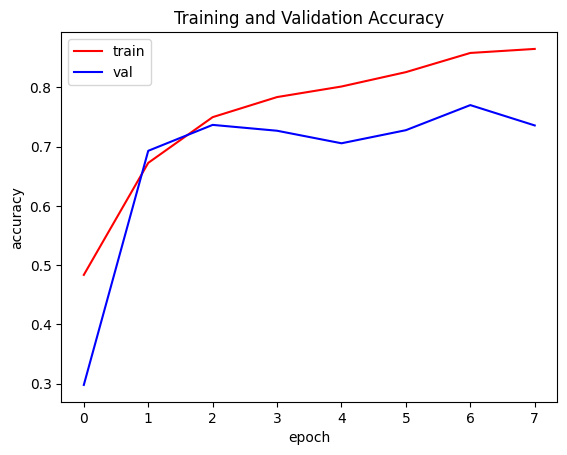

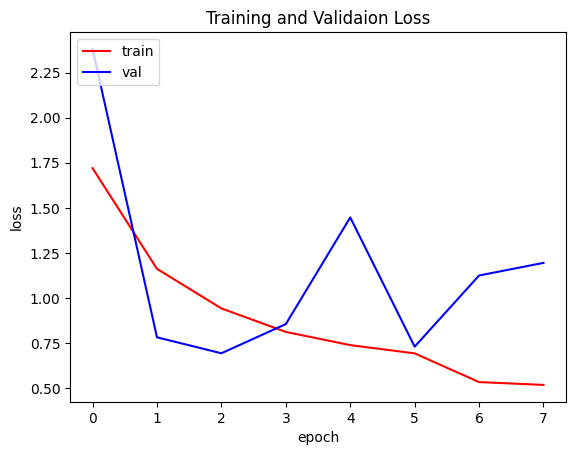

In [ ]:
import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(len(acc))

plt.plot(epochs, acc, 'r')
plt.plot(epochs, val_acc, 'b')
plt.title('Training and Validation Accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

plt.plot(epochs, loss, 'r')
plt.plot(epochs, val_loss, 'b')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.title('Training and Validaion Loss')
plt.show()

## Konversi Model

In [ ]:
## TFJS_MODEL

# Convert model.h5 to model
!tensorflowjs_converter --input_format=keras best_model.h5 tfjs_model

2026-02-27 11:32:55.835993: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772191976.223327   26850 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772191976.320246   26850 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772191977.045730   26850 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772191977.045882   26850 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772191977.045888   26850 computation_placer.cc:177] computation placer alr

In [ ]:
# 1. Inisialisasi converter dari model Keras
converter = tf.lite.TFLiteConverter.from_keras_model(model_1)

# 2. (Opsional) Optimasi: Mengecilkan ukuran model (Quantization)
# Ini akan mengubah bobot dari float32 ke format yang lebih kecil tanpa banyak mengurangi akurasi
converter.optimizations = [tf.lite.Optimize.DEFAULT]

# 3. Lakukan konversi
tflite_model = converter.convert()

# 4. Simpan ke file .tflite
with open('model_cnn.tflite', 'wb') as f:
    f.write(tflite_model)

print("Model berhasil disimpan sebagai model_cnn.tflite")

# Ambil daftar nama kelas dari generator
class_names = list(test_generator.class_indices.keys())

# Simpan ke file labels.txt
with open('labels.txt', 'w') as f:
    for name in class_names:
        f.write(name + '\n')

print("File labels.txt berhasil dibuat!")

Saved artifact at '/tmp/tmp5nh0zhz0'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 150, 150, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  135177048724432: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135177048725584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135177048724624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135177048726352: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135177048723088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135177048724240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135177048725008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135177048727696: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135177048729040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135177048729424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1351770487288

In [ ]:
# Tentukan nama folder tempat model akan disimpan
export_dir = 'saved_model'

# Simpan model dalam format SavedModel
model_1.export(export_dir)

print(f"Model berhasil disimpan di folder: {export_dir}")

Saved artifact at 'saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 150, 150, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  135177048724432: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135177048725584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135177048724624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135177048726352: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135177048723088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135177048724240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135177048725008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135177048727696: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135177048729040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135177048729424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135177048728848: T

## Inference (Optional)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


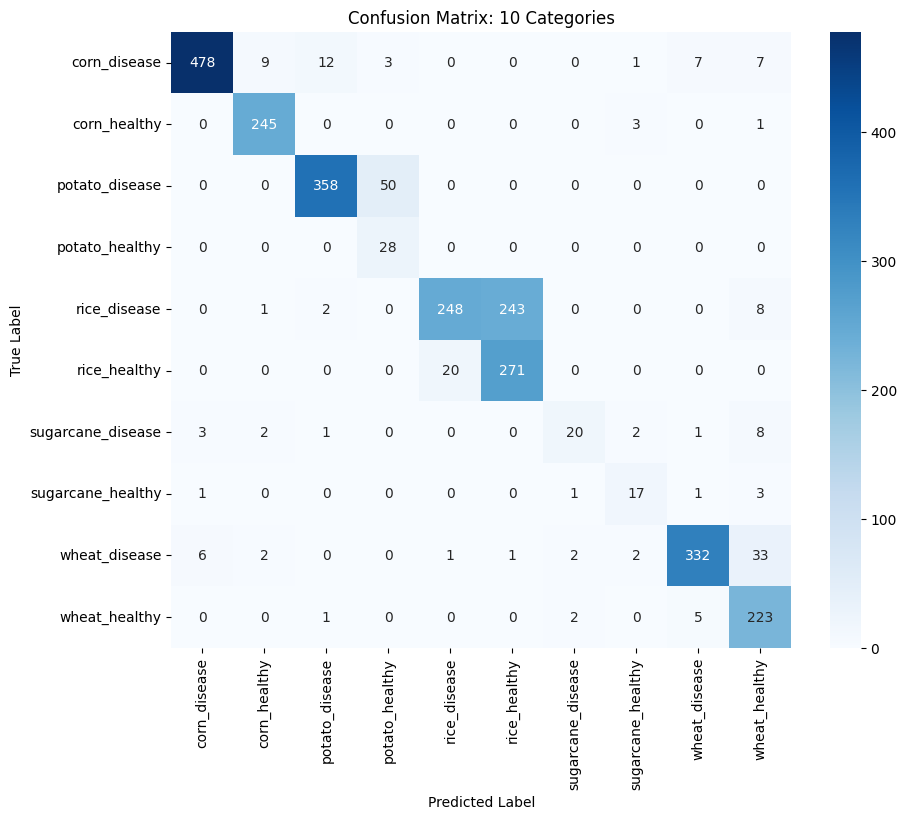

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

preds_1 = model_1.predict(test_generator,verbose=0)
preds_1 = preds_1.copy()
pred_labels = np.argmax(preds_1, axis=1)

true_labels = test_generator.classes

class_names = list(test_generator.class_indices.keys())
cm = confusion_matrix(true_labels, pred_labels)

# Plotting
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix: 10 Categories')
plt.show()


In [ ]:
!pip freeze > requirements.txt

In [29]:
!rm -rf "/content/folder_A" "/content/Crop Diseases Dataset" "/content/Dataset-Final" "/content/five-crop-diseases-dataset.zip"

In [30]:
# 1. Pindah ke direktori /content
%cd /content

# 2. Zip semua isi direktori saat ini (.)
# -x digunakan untuk mengecualikan (exclude) file zip itu sendiri dan folder sistem
!zip -r submission.zip . -x "sample_data/*" "submission.zip" ".config/*"

/content
  adding: saved_model/ (stored 0%)
  adding: saved_model/variables/ (stored 0%)
  adding: saved_model/variables/variables.data-00000-of-00001 (deflated 8%)
  adding: saved_model/variables/variables.index (deflated 71%)
  adding: saved_model/fingerprint.pb (stored 0%)
  adding: saved_model/assets/ (stored 0%)
  adding: saved_model/saved_model.pb (deflated 87%)
  adding: kaggle.json (stored 0%)
  adding: best_model.h5 (deflated 8%)
  adding: tfjs_model/ (stored 0%)
  adding: tfjs_model/group1-shard1of2.bin (deflated 8%)
  adding: tfjs_model/model.json (deflated 89%)
  adding: tfjs_model/group1-shard2of2.bin (deflated 8%)
  adding: .ipynb_checkpoints/ (stored 0%)
  adding: labels.txt (deflated 53%)
  adding: model_cnn.tflite (deflated 2%)
  adding: requirements.txt (deflated 57%)


In [31]:
!du -sh submission.zip

26M	submission.zip
